# EDA + PREPROCESSING PLAN
```
EDA_PM2.5:
├── Tổng quan cấu trúc & thống kê mô tả
├── Missing value & gap analysis
├── Distribution & Outlier detection
├── Daily & Weekly pattern
├── Rolling mean visualization
├── Correlation Analysis: PM2.5 ↔ Meteo correlation (+ lag correlation)
└── ACF/PACF (inform lag selection cho FE)

EDA_Meteo:
├── Missing value check      → có cần impute không
├── Range hợp lý không       → nhiệt độ âm ở HCMC? vô lý → flag
└── Correlation với PM2.5    → feature nào quan trọng

Merge
└── pm25_imputed + meteo_df → clean_data
```

# 0. Setup path

In [23]:
# Chuyển sang Markdown: Nhấn Esc sau đó nhấn M.
# Chuyển sang Code: Nhấn Esc sau đó nhấn Y.

import os
from pathlib import Path

import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
PM25_FILE = DATA_RAW / "pm25_sensor_11357424.csv"
WEATHER_FILE = DATA_RAW / "weather_openmeteo.csv"

print(f"PM2.5 file: {PM25_FILE.exists()}, Weather file: {WEATHER_FILE.exists()}")

PM2.5 file: True, Weather file: True


# 1. Load Data

In [15]:
from IPython.display import display

pm25_df = (
    pd.read_csv(PM25_FILE)
      .rename(columns=str.lower)
)

weather_df = (
    pd.read_csv(WEATHER_FILE)
      .rename(columns=str.lower)
)

# Bảo đảm cột thời gian tồn tại
pm25_df["datetime"] = pd.to_datetime(pm25_df["datetime"], utc=True)
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"], utc=True)

# Lọc dữ liệu trong khoảng cùng thời gian với PM2.5 
start_date = "2024-11-19 10:00:00+00:00"
end_date = "2026-03-22 23:00:00+00:00"

weather_df = weather_df[(weather_df['datetime'] >= start_date) & 
                        (weather_df['datetime'] <= end_date)]

print(f"PM2.5 shape: {pm25_df.shape}")
display(pm25_df.head(5))
print()
print(f"Weather shape: {weather_df.shape}")
display(weather_df.head(5))

PM2.5 shape: (10409, 7)


,datetime,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,NaN,30.950000,100.0
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,NaN,30.216667,100.0



Weather shape: (11726, 10)


,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
10,2024-11-19 10:00:00+00:00,32.0,55,0.0,1.57,59,1006.8,910.0,-1.345753,-0.808610
11,2024-11-19 11:00:00+00:00,30.9,59,0.1,0.29,211,1007.6,150.0,0.149361,0.248579
12,2024-11-19 12:00:00+00:00,29.3,68,0.0,1.37,204,1008.4,245.0,0.557229,1.251557
13,2024-11-19 13:00:00+00:00,26.6,77,0.2,0.78,105,1009.5,95.0,-0.753422,0.201879
14,2024-11-19 14:00:00+00:00,26.6,79,0.1,1.10,309,1010.0,85.0,0.854861,-0.692252


# 2. EDA

## 2.1. Kiểm tra nhanh
Check shape, dtype, range thời gian, thống kê mô tả

### a) PM2.5

In [16]:
pm25_df.head(5)

,datetime,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,NaN,30.950000,100.0
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,NaN,30.216667,100.0


In [17]:
pm25_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10409 entries, 0 to 10408
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   datetime      10409 non-null  datetime64[ns, UTC]
 1   pm25_avg      10409 non-null  float64            
 2   pm25_min      10409 non-null  float64            
 3   pm25_max      10409 non-null  float64            
 4   pm25_sd       0 non-null      float64            
 5   pm25_median   10409 non-null  float64            
 6   coverage_pct  10409 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(6)
memory usage: 569.4 KB


In [18]:
pm25_df.describe()

,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
count,10409.000000,10409.000000,10409.000000,0.0,10409.000000,10409.0
mean,34.656911,34.656911,34.656911,NaN,34.656911,100.0
std,17.319568,17.319568,17.319568,NaN,17.319568,0.0
min,2.916958,2.916958,2.916958,NaN,2.916958,100.0
25%,22.800000,22.800000,22.800000,NaN,22.800000,100.0
50%,31.800000,31.800000,31.800000,NaN,31.800000,100.0
75%,42.478167,42.478167,42.478167,NaN,42.478167,100.0
max,171.267000,171.267000,171.267000,NaN,171.267000,100.0


In [19]:
pm25_df.isna().sum()

datetime            0
pm25_avg            0
pm25_min            0
pm25_max            0
pm25_sd         10409
pm25_median         0
coverage_pct        0
dtype: int64

### (*) KIỂM TRA MISSING GAP - DATA CONTINUITY

In [24]:
pm25_df2 = (
    pm25_df
    .set_index("datetime")
    .sort_index()
 )
print(pm25_df2.shape)
print(pm25_df2.index.min(), pm25_df2.index.max())

full_range = pd.date_range(pm25_df2.index.min(), pm25_df2.index.max(), freq="h")
print(full_range.shape)

(10409, 6)
2024-11-19 10:00:00+00:00 2026-03-22 23:00:00+00:00
(11726,)


In [25]:
# Lấp đầy các khoảng trống thời gian (gap) trong dữ liệu bằng giá trị NaN.
pm25_df_full = pm25_df2.reindex(full_range)
pm25_df_full.index.name = "datetime" # đặt lại tên cho cột chỉ mục thành 'datetime' như ban đầu
print("PM2.5 full range: ", pm25_df_full.shape)

pm25_df_full["is_missing_pm25"] = pm25_df_full["pm25_avg"].isna()
print("PM2.5 full range 2: ", pm25_df_full.shape)
missing_hrs = int(pm25_df_full["is_missing_pm25"].sum())
total_hrs = pm25_df_full.shape[0]
print("Mising hrs: ", missing_hrs)
print("Missing hrs in %: ", missing_hrs / total_hrs)

pm25_df_full.head(5)

PM2.5 full range:  (11726, 6)
PM2.5 full range 2:  (11726, 7)
Mising hrs:  1317
Missing hrs in %:  0.11231451475353914


,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct,is_missing_pm25
datetime,,,,,,,
2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0,False
2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0,False
2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0,False
2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,NaN,30.950000,100.0,False
2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,NaN,30.216667,100.0,False


In [26]:
pm25_df_full["gap_group"] = (
    pm25_df_full["is_missing_pm25"].ne(pm25_df_full["is_missing_pm25"].shift()).cumsum()
 )
gap_summary = (
    pm25_df_full.loc[pm25_df_full["is_missing_pm25"]]
    .groupby("gap_group")
    .apply(
        lambda grp: pd.Series({
            "gap_start": grp.index.min(),
            "gap_end": grp.index.max(),
            "gap_hours": grp.shape[0],
        }),
        include_groups=False
    )
    .sort_values("gap_hours", ascending=False)
)

if not gap_summary.empty:
    print("\nList tất cả các đoạn mất dữ liệu (theo giờ liên tiếp):")
    display(gap_summary)
else:
    print("\nKhông phát hiện đoạn mất dữ liệu nào sau reindex.")


List tất cả các đoạn mất dữ liệu (theo giờ liên tiếp):


,gap_start,gap_end,gap_hours
gap_group,,,
22,2025-01-13 23:00:00+00:00,2025-02-11 16:00:00+00:00,690
46,2025-06-07 06:00:00+00:00,2025-06-23 14:00:00+00:00,393
20,2025-01-12 02:00:00+00:00,2025-01-13 15:00:00+00:00,38
52,2025-06-25 11:00:00+00:00,2025-06-26 14:00:00+00:00,28
26,2025-02-14 13:00:00+00:00,2025-02-15 12:00:00+00:00,24
28,2025-05-01 12:00:00+00:00,2025-05-02 03:00:00+00:00,16
30,2025-05-26 03:00:00+00:00,2025-05-26 14:00:00+00:00,12
2,2024-12-16 11:00:00+00:00,2024-12-16 19:00:00+00:00,9
34,2025-06-01 18:00:00+00:00,2025-06-02 02:00:00+00:00,9


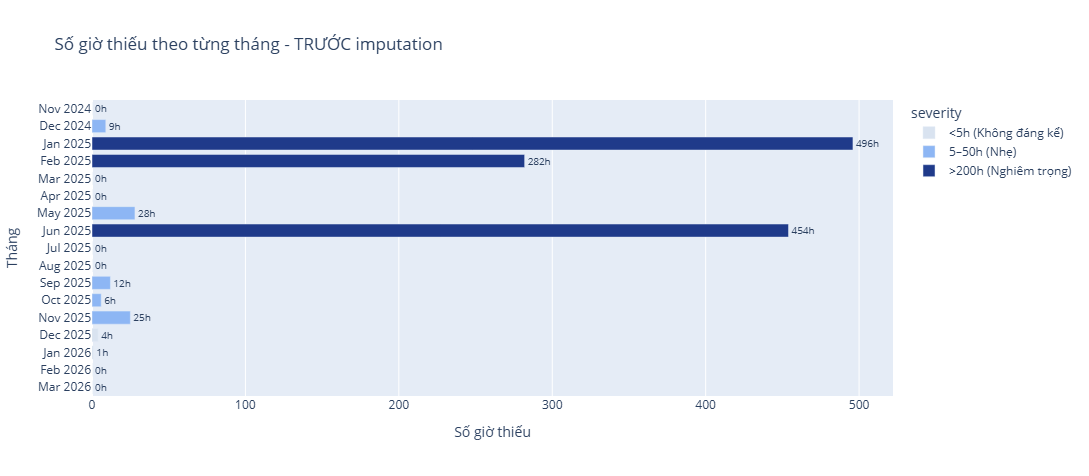

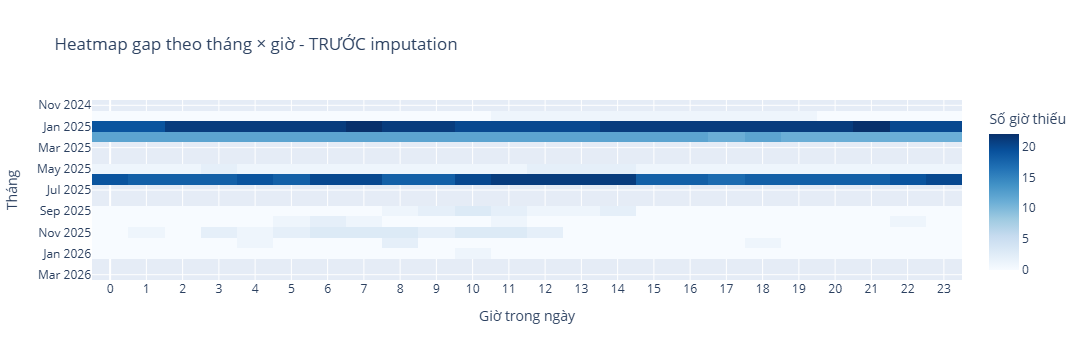

In [28]:
# @title Missing hours by month + heatmap theo giờ
import plotly.express as px
import pandas as pd

# --- Missing hours theo tháng ---
monthly_missing = (
    pm25_df_full["is_missing_pm25"]
    .resample("ME")
    .sum()
    .astype(int)
    .rename("missing_hours")
    .reset_index()
)
monthly_missing["year_month_label"] = monthly_missing["datetime"].dt.strftime("%b %Y")
monthly_missing["severity"] = pd.cut(
    monthly_missing["missing_hours"],
    bins=[-1, 5, 50, 200, float("inf")],
    labels=["<5h (Không đáng kể)", "5–50h (Nhẹ)", "50–200h (Trung bình)", ">200h (Nghiêm trọng)"],
    ordered=True,
).cat.remove_unused_categories().astype(str)

# Sort theo datetime để giữ thứ tự thời gian
monthly_missing = monthly_missing.sort_values("datetime", ascending=False)

fig_missing = px.bar(
    monthly_missing,
    x="missing_hours",
    y="year_month_label",
    color="severity",
    orientation="h",
    text="missing_hours",
    color_discrete_map={
        "<5h (Không đáng kể)": "#d9e3f0",
        "5–50h (Nhẹ)"        : "#8db6f4",
        "50–200h (Trung bình)": "#4472c4",
        ">200h (Nghiêm trọng)": "#1f3a8a",
    },
    labels={"missing_hours": "Số giờ thiếu", "year_month_label": "Tháng"},
    title="Số giờ thiếu theo từng tháng - TRƯỚC imputation",
)
fig_missing.update_traces(texttemplate="%{text}h", textposition="outside")
fig_missing.update_layout(
    yaxis=dict(
        categoryorder="array",
        categoryarray=monthly_missing["year_month_label"].tolist(),  # đúng thứ tự thời gian
    ),
    bargap=0.25,
    height=max(400, len(monthly_missing) * 28),  # tự scale chiều cao theo số tháng
)
fig_missing.show()

# --- Heatmap thiếu theo tháng × giờ ---
# Tạo đúng thứ tự tháng theo thời gian cho heatmap
month_order = (
    monthly_missing
    .sort_values("datetime", ascending=True)["year_month_label"]
    .tolist()
)

heatmap_df = (
    pm25_df_full.loc[pm25_df_full["is_missing_pm25"]]
    .reset_index()
    .assign(
        year_month=lambda df: df["datetime"].dt.strftime("%b %Y"),
        hour      =lambda df: df["datetime"].dt.hour,
    )
    .groupby(["year_month", "hour"], observed=False)
    .size()
    .rename("missing_count")
    .reset_index()
)

heatmap_pivot = (
    heatmap_df.pivot(index="year_month", columns="hour", values="missing_count")
    .fillna(0)
    .reindex(month_order)   # đảm bảo thứ tự tháng chronological
)

fig_heatmap = px.imshow(
    heatmap_pivot,
    aspect="auto",
    color_continuous_scale="Blues",
    labels=dict(color="Số giờ thiếu"),
    title="Heatmap gap theo tháng × giờ - TRƯỚC imputation",
)
fig_heatmap.update_xaxes(title="Giờ trong ngày", dtick=1)
fig_heatmap.update_yaxes(title="Tháng", autorange="reversed")
fig_heatmap.show()

### * Kết luận từ phân tích Missing Data
Nhìn vào bar chart và gap table, missing không phân bố ngẫu nhiên mà tập trung rõ rệt:

- Jan–Feb 2025: 496h + 282h = ~778h → chiếm ~59% tổng missing
- Jun 2025: 454h → chiếm ~35% tổng missing
- Còn lại (Dec 2024, May, Sep, Oct, Nov 2025): tổng ~85h → rải rác, nhỏ lẻ

→ 2 cụm gap lớn + nhiều gap nhỏ lẻ — đây là pattern sensor bị offline theo đợt, không phải lỗi ngẫu nhiên.


### * Đánh giá theo impute strategy

| Gap group | Số gap | Tổng giờ | Quyết định | Lý do |
| :--- | :---: | :---: | :--- | :--- |
| **1h** (single point) | ~20 gap | ~20h | **Tier 1: Linear** | Quá ngắn, nội suy tuyến tính (Linear Interpolate) rất an toàn. |
| **2-3h** | ~5 gap | ~12h | **Tier 1: Linear** | Khoảng cách ngắn, biến thiên tuyến tính vẫn chấp nhận được. |
| **4-24h** | ~10 gap | ~120h | **Tier 2: Hourly Median** | Có đặc tính chu kỳ ngày rõ rệt, dùng Median ±7 ngày là hợp lý. |
| **25-168h** | 2 gap (38h, 28h, 24h, 16h) | ~106h | **Tier 3: Rolling Median** | Vẫn đủ dữ liệu xung quanh để ước lượng (Estimate). |
| **>168h** | 2 gap (690h, 393h) | ~1083h | **Không impute - Flag** | Khoảng trống quá dài, việc bù dữ liệu sẽ tạo ra sai số lớn (Data giả). |


---

### (*) IMPUTE STRATEGY: Chiến lược nội suy PM2.5 đa tầng

Chiến lược đa tầng theo bảng này:

| Tier | Khoảng Gap | Phương pháp xử lý |
| :--- | :--- | :--- |
| **1** | 1-3h | `interpolate(method='time')` |
| **2** | 4-24h | Median của cùng khung giờ trong ± 7 ngày |
| **3** | 25-168h (1 tuần) | Rolling median 7 ngày theo giờ |
| **4** | >168h | Không impute - đánh flag `is_imputed=large_gap` |

===> Gap 690h và 393h, 385h → giữ NaN, flag lại, không nên impute vì sẽ tạo dữ liệu giả quá dài.


In [30]:
import numpy as np
import pandas as pd

# ── Tạo bản copy, giữ nguyên pm25_df_full ────────────────────
pm25_imputed = pm25_df_full.copy()

# ── 0. Cột tracking ──────────────────────────────────────────
pm25_imputed['is_imputed'] = 0

LARGE_GAP_THRESHOLD = 168

mask_na = pm25_imputed['pm25_avg'].isna()
gap_id  = (mask_na != mask_na.shift()).cumsum()
gap_df  = (
    pm25_imputed[mask_na]
    .assign(gap_id=gap_id[mask_na])
    .groupby('gap_id')
    .agg(
        gap_start=('pm25_avg', lambda x: x.index.min()),
        gap_end  =('pm25_avg', lambda x: x.index.max()),
        gap_hours=('pm25_avg', lambda x: len(x))
    )
    .reset_index(drop=True)
)

large_gaps = gap_df[gap_df['gap_hours'] > LARGE_GAP_THRESHOLD]
for _, row in large_gaps.iterrows():
    pm25_imputed.loc[row['gap_start']:row['gap_end'], 'is_imputed'] = 3

# ── 1. Tier 1 — Linear interpolate (gap ≤ 3h) ───────────────
def flag_and_interpolate_tier1(df, col='pm25_avg', max_gap=3):
    s       = df[col].copy()
    na_mask = s.isna()
    run_len = na_mask.groupby((na_mask != na_mask.shift()).cumsum()).transform('sum')
    eligible = na_mask & (run_len <= max_gap) & (df['is_imputed'] == 0)
    df.loc[eligible, 'is_imputed'] = 1
    df[col] = s.interpolate(method='time', limit=max_gap)
    return df

pm25_imputed = flag_and_interpolate_tier1(pm25_imputed)

# ── 2. Tier 2 — Median cùng giờ ± 7 ngày (gap 4–24h) ────────
def tier2_hourly_median(df, col='pm25_avg', max_gap=24, window_days=7):
    s        = df[col].copy()
    filled   = s.copy()
    still_na = df[col].isna() & (df['is_imputed'] == 0)
    na_idx   = df.index[still_na]
    na_mask  = df[col].isna()
    run_len  = na_mask.groupby((na_mask != na_mask.shift()).cumsum()).transform('sum')
    for ts in na_idx:
        if run_len[ts] > max_gap:
            continue
        hour      = ts.hour
        window    = pd.date_range(ts - pd.Timedelta(days=window_days),
                                  ts + pd.Timedelta(days=window_days), freq='1h')
        same_hour = s[s.index.isin(window) & (s.index.hour == hour)]
        val       = same_hour.median()
        if not np.isnan(val):
            filled[ts]              = val
            df.loc[ts, 'is_imputed'] = 2
    df[col] = filled
    return df

pm25_imputed = tier2_hourly_median(pm25_imputed)

# ── 3. Tier 3 — Rolling median 7 ngày (gap 25–168h) ─────────
def tier3_rolling_median(df, col='pm25_avg', window='7D'):
    s        = df[col].copy()
    roll_med = s.rolling(window, center=True, min_periods=24).median()
    still_na = df[col].isna() & (df['is_imputed'] == 0)
    df.loc[still_na, col]          = roll_med[still_na]
    df.loc[still_na, 'is_imputed'] = 3
    return df

pm25_imputed = tier3_rolling_median(pm25_imputed)

# ── Summary ──────────────────────────────────────────────────
print("Imputation summary:")
print(pm25_imputed['is_imputed'].value_counts().sort_index().rename({
    0: '0 - Original',
    1: '1 - Linear (≤3h)',
    2: '2 - Hourly median (4-24h)',
    3: '3 - Rolling median / Large gap (flag)'
}))
print(f"\nStill NaN : {pm25_imputed['pm25_avg'].isna().sum()}")
print(f"pm25_df_full NaN (unchanged): {pm25_df_full['pm25_avg'].isna().sum()}")

Imputation summary:
is_imputed
0 - Original                             10457
1 - Linear (≤3h)                            44
2 - Hourly median (4-24h)                   82
3 - Rolling median / Large gap (flag)     1143
Name: count, dtype: int64

Still NaN : 1077
pm25_df_full NaN (unchanged): 1317


In [31]:
# Kiểm tra các gap NaN còn lại sau imputation
mask_na = pm25_imputed['pm25_avg'].isna()
gap_id  = (mask_na != mask_na.shift()).cumsum()

remaining_gaps = (
    pm25_imputed[mask_na]
    .groupby(gap_id)
    .agg(
        gap_start=('pm25_avg', lambda x: x.index.min()),
        gap_end  =('pm25_avg', lambda x: x.index.max()),
        gap_hours=('pm25_avg', lambda x: len(x))
    )
    .reset_index(drop=True)
    .sort_values('gap_hours', ascending=False)
)

print(remaining_gaps)
print(f"\nTổng NaN còn lại: {remaining_gaps['gap_hours'].sum()}")

                  gap_start                   gap_end  gap_hours
0 2025-01-14 02:00:00+00:00 2025-02-11 16:00:00+00:00        687
1 2025-06-07 09:00:00+00:00 2025-06-23 14:00:00+00:00        390

Tổng NaN còn lại: 1077


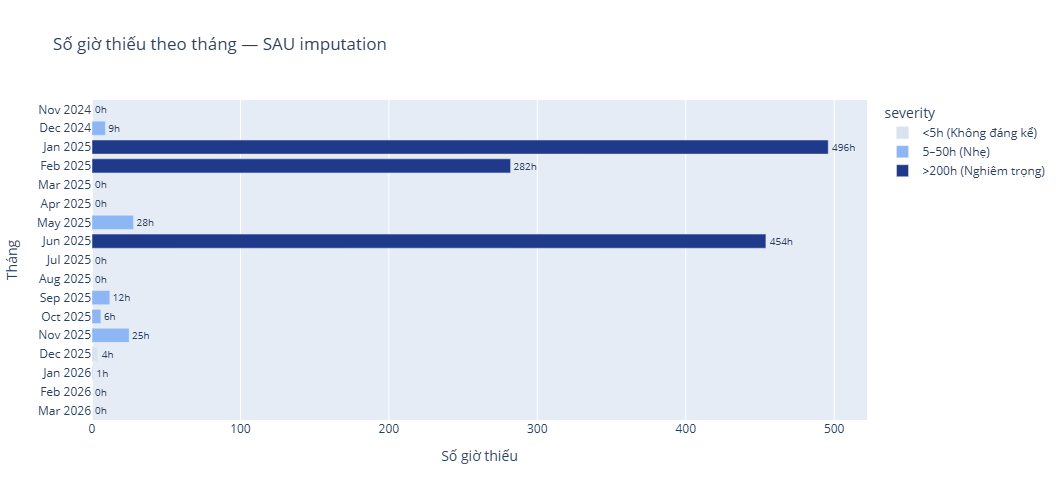

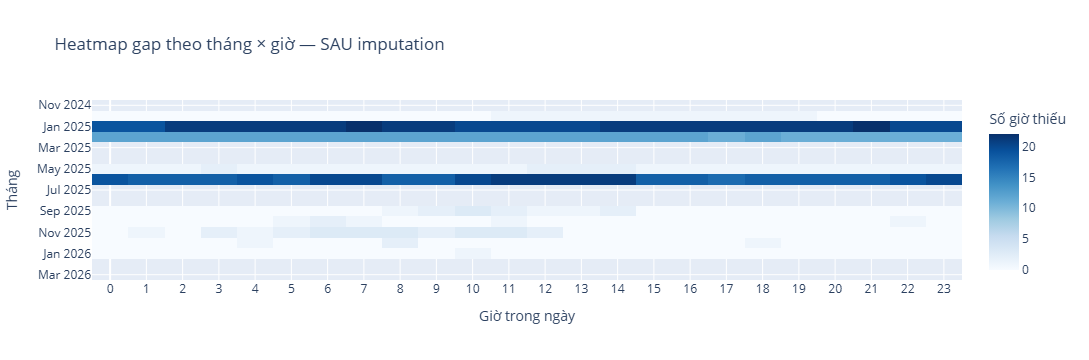

In [50]:
# Sort theo chronological order thay vì ascending value

monthly_missing2 = (
    pm25_df_full["is_missing_pm25"]
    .resample("ME")
    .sum()
    .astype(int)
    .rename("missing_hours")
    .reset_index()
)
monthly_missing2["year_month_label"] = monthly_missing2["datetime"].dt.strftime("%b %Y")

bins = [-1, 5, 50, 200, float("inf")]
labels = ["<5h (Không đáng kể)", "5–50h (Nhẹ)", "50–200h (Trung bình)", ">200h (Nghiêm trọng)"]
monthly_missing2["severity"] = pd.cut(monthly_missing2["missing_hours"], bins=bins, labels=labels)
monthly_missing2["severity"] = monthly_missing2["severity"].cat.remove_unused_categories().astype(str)


monthly_missing2 = monthly_missing2.sort_values('datetime', ascending=False)  # mới nhất trên cùng

fig_missing2 = px.bar(
    monthly_missing2,
    x='missing_hours', y='year_month_label',
    color='severity', orientation='h', text='missing_hours',
    color_discrete_map={
        '<5h (Không đáng kể)' : '#d9e3f0',
        '5–50h (Nhẹ)'         : '#8db6f4',
        '50–200h (Trung bình)': '#4472c4',
        '>200h (Nghiêm trọng)': '#1f3a8a',
    },
    labels={'missing_hours': 'Số giờ thiếu', 'year_month_label': 'Tháng'},
    title='Số giờ thiếu theo tháng — SAU imputation',
)
fig_missing2.update_traces(texttemplate='%{text}h', textposition='outside')
fig_missing2.update_layout(
    yaxis=dict(
        categoryorder='array',
        categoryarray=monthly_missing2['year_month_label'].tolist(),  # giữ đúng thứ tự datetime
    ),
    bargap=0.25,
    height=500  # tăng chiều cao để các tháng không bị chen nhau
)
fig_missing2.show()



# --- Heatmap thiếu theo tháng × giờ --- SAU imputation
month_order2 = (
    monthly_missing2
    .sort_values("datetime", ascending=True)["year_month_label"]
    .tolist()
)

heatmap_df2 = (
    pm25_imputed[pm25_imputed["is_missing_pm25"]]   # ← dùng pm25_imputed, không phải pm25_df_full
    .reset_index()
    .assign(
        year_month=lambda df: df["datetime"].dt.strftime("%b %Y"),
        hour      =lambda df: df["datetime"].dt.hour,
    )
    .groupby(["year_month", "hour"], observed=False)
    .size()
    .rename("missing_count")
    .reset_index()
)

heatmap_pivot2 = (
    heatmap_df2.pivot(index="year_month", columns="hour", values="missing_count")  # ← heatmap_df2
    .fillna(0)
    .reindex(month_order2)   # ← month_order2
)

if heatmap_pivot2.empty or heatmap_pivot2.sum().sum() == 0:
    print("Không còn missing sau imputation — heatmap không cần thiết.")
else:
    fig_heatmap2 = px.imshow(
        heatmap_pivot2,
        aspect="auto",
        color_continuous_scale="Blues",
        labels=dict(color="Số giờ thiếu"),
        title="Heatmap gap theo tháng × giờ — SAU imputation",
    )
    fig_heatmap2.update_xaxes(title="Giờ trong ngày", dtick=1)
    fig_heatmap2.update_yaxes(title="Tháng", autorange="reversed")
    fig_heatmap2.show()

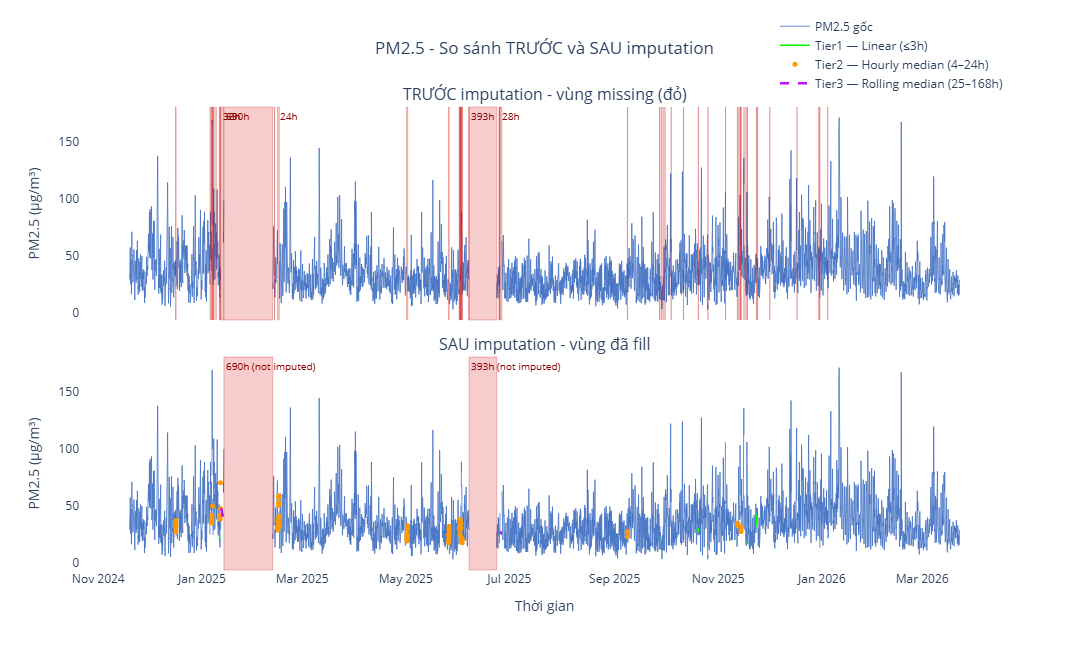

In [52]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=[
        'TRƯỚC imputation - vùng missing (đỏ)',
        'SAU imputation - vùng đã fill',
    ]
)

# ══ Row 1: TRƯỚC imputation ═══════════════════════════════════
fig.add_trace(go.Scatter(
    x=pm25_df_full.index,
    y=pm25_df_full['pm25_avg'],
    mode='lines',
    line=dict(color='#4472c4', width=0.8),
    name='PM2.5 gốc',
), row=1, col=1)

for _, row in gap_summary.iterrows():
    fig.add_vrect(
        x0=row['gap_start'],
        x1=row['gap_end'] + pd.Timedelta(hours=1),
        fillcolor='rgba(220, 50, 50, 0.25)',
        line=dict(color='rgba(200, 0, 0, 0.5)', width=0.5),
        annotation_text=f"{row['gap_hours']}h" if row['gap_hours'] >= 24 else "",
        annotation_position="top left",
        annotation_font=dict(size=10, color='darkred'),
        row=1, col=1,
    )

# ══ Row 2: SAU imputation ═════════════════════════════════════
# -- Data gốc (không bị impute)
fig.add_trace(go.Scatter(
    x=pm25_imputed.index,
    y=pm25_imputed['pm25_avg'].where(pm25_imputed['is_imputed'] == 0),
    mode='lines',
    line=dict(color='#4472c4', width=0.8),
    name='PM2.5 gốc',
    legendgroup='original',
    showlegend=False,
), row=2, col=1)

# -- Tier 1: linear (xanh lá nhạt)
fig.add_trace(go.Scatter(
    x=pm25_imputed.index,
    y=pm25_imputed['pm25_avg'].where(pm25_imputed['is_imputed'] == 1),
    mode='lines',
    line=dict(color='#00FF00  ', width=1.5),
    name='Tier1 — Linear (≤3h)',
), row=2, col=1)

# -- Tier 2: hourly median (cam)
fig.add_trace(go.Scatter(
    x=pm25_imputed.index,
    y=pm25_imputed['pm25_avg'].where(pm25_imputed['is_imputed'] == 2),
    mode='markers',
    marker=dict(color='#ff9900', size=5),
    name='Tier2 — Hourly median (4–24h)',
), row=2, col=1)

# -- Tier 3: rolling median (tím)
fig.add_trace(go.Scatter(
    x=pm25_imputed.index,
    y=pm25_imputed['pm25_avg'].where(pm25_imputed['is_imputed'] == 3),
    mode='lines',
    line=dict(color='#BC13FE', width=2.5, dash='dash'),
    name='Tier3 — Rolling median (25–168h)',
), row=2, col=1)

# -- Large gap còn NaN: vẫn tô đỏ
remaining_gaps = gap_summary[gap_summary['gap_hours'] > 168]
for _, row in remaining_gaps.iterrows():
    fig.add_vrect(
        x0=row['gap_start'],
        x1=row['gap_end'] + pd.Timedelta(hours=1),
        fillcolor='rgba(220, 50, 50, 0.25)',
        line=dict(color='rgba(200, 0, 0, 0.5)', width=0.5),
        annotation_text=f"{row['gap_hours']}h (not imputed)",
        annotation_position="top left",
        annotation_font=dict(size=10, color='darkred'),
        row=2, col=1,
    )

# ══ Layout ════════════════════════════════════════════════════
fig.update_yaxes(title_text='PM2.5 (μg/m³)', row=1, col=1)
fig.update_yaxes(title_text='PM2.5 (μg/m³)', row=2, col=1)
fig.update_xaxes(title_text='Thời gian', row=2, col=1)

fig.update_layout(
    title=dict(text='PM2.5 - So sánh TRƯỚC và SAU imputation', x=0.5),
    height=650,
    plot_bgcolor='white',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)

fig.show()

### * Giải thích màu sau khi impute:

| Màu sắc | Ý nghĩa | Phương pháp xử lý |
| :--- | :--- | :--- |
| 🟦 **Xanh dương** | **Data gốc** | Dữ liệu thực tế từ trạm đo. |
| 🟩 **Xanh lá** | **Tier 1** | Nội suy tuyến tính (**Linear Interpolate**) cho gap ngắn (≤3h). |
| 🟧 **Cam (chấm)** | **Tier 2** | Dùng trung vị theo giờ (**Hourly Median**) cho gap từ 4–24h. |
| 🟪 **Tím (đứt)** | **Tier 3** | Dùng trung vị trượt (**Rolling Median**) cho gap từ 25–168h. |
| 🟥 **Đỏ** | **Large Gap** | Khoảng trống >168h - **Không xử lý** (Gắn Flag để tránh tạo data giả). |


### b) Weather

In [18]:
weather_df.shape

(11726, 10)

In [34]:
meteo = (
    weather_df
    .set_index("datetime")
    .sort_index()
 )
print(meteo.shape)
print(meteo.index.min(), meteo.index.max())

full_range = pd.date_range(meteo.index.min(), meteo.index.max(), freq="h")
full_range.shape

(11726, 9)
2024-11-19 10:00:00+00:00 2026-03-22 23:00:00+00:00


(11726,)

In [35]:
weather_df.describe()

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
count,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000
mean,27.345216,76.789528,0.247757,1.889033,185.606345,1009.084701,553.184377,-0.025693,0.398321
std,3.145368,17.365698,1.054782,0.999279,98.104275,2.406897,518.727565,1.478327,1.490813
min,17.900000,22.000000,0.000000,0.000000,1.000000,1001.800000,10.000000,-5.205118,-5.141389
25%,25.000000,66.000000,0.000000,1.130000,119.000000,1007.400000,165.000000,-1.095619,-0.653151
50%,26.600000,81.000000,0.000000,1.770000,178.000000,1009.000000,370.000000,-0.045342,0.452548
75%,29.500000,91.000000,0.000000,2.530000,258.000000,1010.700000,780.000000,0.905893,1.541835
max,37.300000,100.000000,18.800000,6.510000,360.000000,1017.100000,2800.000000,6.150000,5.802971


In [36]:
weather_df.isna().mean().mul(100).round(2)

datetime                 0.0
temperature_2m           0.0
relative_humidity_2m     0.0
precipitation            0.0
wind_speed_10m           0.0
wind_direction_10m       0.0
surface_pressure         0.0
boundary_layer_height    0.0
wind_u                   0.0
wind_v                   0.0
dtype: float64

## 2.2. Distribution & Outliers

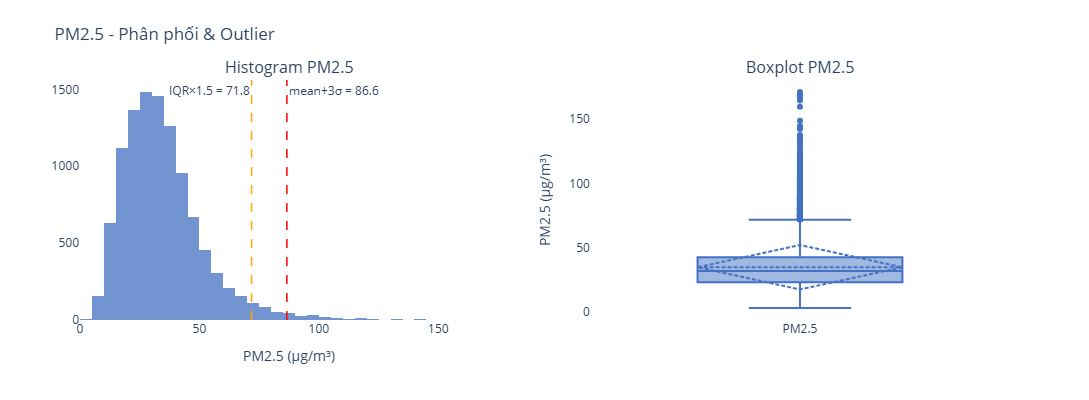

Outlier (mean+3σ > 86.6): 169 điểm (1.59%)
Outlier (IQR×1.5 > 71.8) : 380 điểm (3.57%)


In [42]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import acf, pacf

# Dùng data đã impute, bỏ NaN (large gap) để tính toán
pm25_clean = pm25_imputed['pm25_avg'].dropna()

# ════════════════════════════════════════════════════════════
# 1. DISTRIBUTION & OUTLIER
# ════════════════════════════════════════════════════════════
mean  = pm25_clean.mean()
std   = pm25_clean.std()
q1    = pm25_clean.quantile(0.25)
q3    = pm25_clean.quantile(0.75)
iqr   = q3 - q1
upper_3std = mean + 3 * std
upper_iqr  = q3 + 1.5 * iqr

fig1 = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Histogram PM2.5', 'Boxplot PM2.5']
)

# Histogram
fig1.add_trace(go.Histogram(
    x=pm25_clean,
    nbinsx=60,
    marker_color='#4472c4',
    opacity=0.75,
    name='PM2.5',
), row=1, col=1)

# Đường ngưỡng outlier
for val, label, color, pos in [
    (upper_3std, f'mean+3σ = {upper_3std:.1f}', 'red', 'top right'),
    (upper_iqr,  f'IQR×1.5 = {upper_iqr:.1f}',  'orange', 'top left'), # Chuyển sang trái để không bị đè
]:
    fig1.add_vline(
        x=val, 
        line=dict(color=color, dash='dash', width=1.5),
        annotation_text=label, 
        annotation_position=pos,
        row=1, col=1
    )

# Boxplot
fig1.add_trace(go.Box(
    y=pm25_clean,
    marker_color='#4472c4',
    boxmean='sd',
    name='PM2.5',
), row=1, col=2)

fig1.update_layout(
    title='PM2.5 - Phân phối & Outlier',
    height=400, 
    showlegend=False, 
    plot_bgcolor='white', 
    margin=dict(t=80)  # Bỏ dấu ngoặc đơn dư thừa ở đây
)

fig1.update_xaxes(title_text='PM2.5 (μg/m³)', row=1, col=1)
fig1.update_yaxes(title_text='PM2.5 (μg/m³)', row=1, col=2)
fig1.show()

n_outlier_3std = (pm25_clean > upper_3std).sum()
n_outlier_iqr  = (pm25_clean > upper_iqr).sum()
print(f"Outlier (mean+3σ > {upper_3std:.1f}): {n_outlier_3std} điểm ({n_outlier_3std/len(pm25_clean)*100:.2f}%)")
print(f"Outlier (IQR×1.5 > {upper_iqr:.1f}) : {n_outlier_iqr} điểm ({n_outlier_iqr/len(pm25_clean)*100:.2f}%)")


**=> Right-skewed**

In [23]:
# Kiểm tra nhanh
print(f"Giá trị min : {pm25_clean.min():.1f}")
print(f"Giá trị max : {pm25_clean.max():.1f}")

# Spike 1 điểm: tăng/giảm đột ngột > 3σ trong 1 giờ
diff = pm25_clean.diff().abs()
spike_1pt = diff[diff > 3 * diff.std()]
print(f"\nSpike 1 giờ (>3σ diff): {len(spike_1pt)} điểm")
print(spike_1pt.sort_values(ascending=False).head(10))

Giá trị min : 2.9
Giá trị max : 171.3

Spike 1 giờ (>3σ diff): 369 điểm
datetime
2026-02-16 17:00:00+00:00    123.114999
2026-02-16 18:00:00+00:00    116.403333
2026-03-07 19:00:00+00:00     82.800000
2025-12-13 19:00:00+00:00     80.264500
2026-01-10 23:00:00+00:00     79.471500
2025-12-31 17:00:00+00:00     76.366292
2025-12-16 19:00:00+00:00     74.656833
2025-02-11 17:00:00+00:00     73.667691
2025-03-11 02:00:00+00:00     70.026460
2025-12-31 18:00:00+00:00     67.344833
Name: pm25_avg, dtype: float64


In [24]:
# Spike thực sự = tăng mạnh rồi về ngay giờ sau
pm25_s = pm25_clean.copy()
diff_fwd  = pm25_s.diff().abs()          # thay đổi so với giờ trước
diff_back = pm25_s.diff(-1).abs()        # thay đổi so với giờ sau

threshold = 3 * diff_fwd.std()

# Spike 1 điểm: cả 2 phía đều thay đổi lớn
true_spike = (diff_fwd > threshold) & (diff_back > threshold)
print(f"Spike 1 điểm thực sự: {true_spike.sum()} điểm")
print(pm25_s[true_spike].sort_values(ascending=False).head(10))

Spike 1 điểm thực sự: 76 điểm
datetime
2026-01-11 04:00:00+00:00    171.267000
2026-02-16 17:00:00+00:00    167.386833
2025-03-11 01:00:00+00:00    144.692543
2025-01-07 03:00:00+00:00    142.984501
2025-12-13 19:00:00+00:00    142.489000
2025-01-07 04:00:00+00:00    121.267626
2024-12-05 22:00:00+00:00    117.426249
2025-04-01 08:00:00+00:00    115.122333
2025-11-16 02:00:00+00:00    112.273709
2025-12-16 19:00:00+00:00    109.856167
Name: pm25_avg, dtype: float64


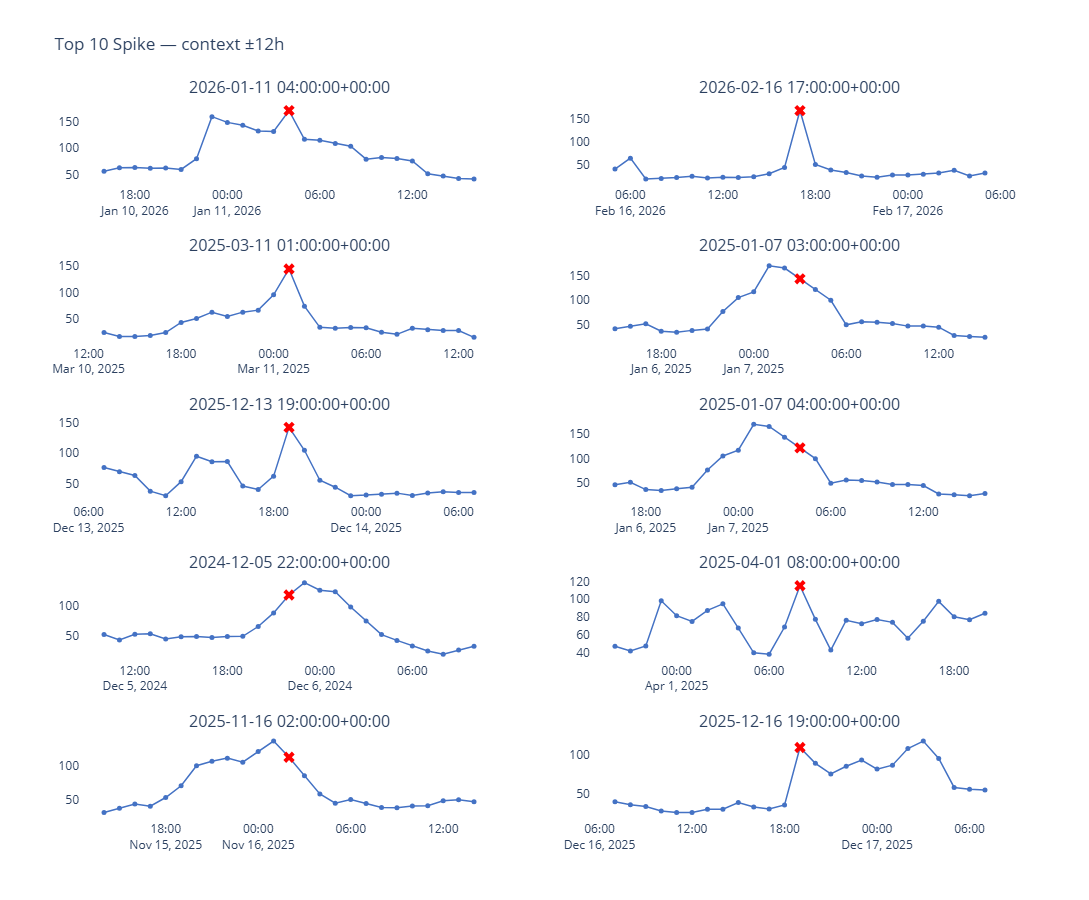

In [25]:
# Plot context ±12h xung quanh mỗi spike để quyết định
spike_times = pm25_s[true_spike].sort_values(ascending=False).index[:10]

fig = make_subplots(rows=5, cols=2, subplot_titles=[str(t) for t in spike_times])

for i, ts in enumerate(spike_times):
    row = i // 2 + 1
    col = i %  2 + 1
    window = pm25_s[ts - pd.Timedelta(hours=12) : ts + pd.Timedelta(hours=12)]
    fig.add_trace(go.Scatter(
        x=window.index, y=window.values,
        mode='lines+markers',
        line=dict(color='#4472c4', width=1.5),
        marker=dict(size=5),
        showlegend=False,
    ), row=row, col=col)
    # Đánh dấu điểm spike
    fig.add_trace(go.Scatter(
        x=[ts], y=[pm25_s[ts]],
        mode='markers',
        marker=dict(color='red', size=10, symbol='x'),
        showlegend=False,
    ), row=row, col=col)

fig.update_layout(height=900, title='Top 10 Spike — context ±12h', plot_bgcolor='white')
fig.show()

**=> 76 spike 1 điểm được kiểm tra visual → tất cả là real event, không phải sensor glitch**

### * Nhận xét:
Không cần winsorize hay drop outlier. Các spike cao là tín hiệu thật (đốt rác, traffic, sự kiện đặc biệt), giữ nguyên để model học được.

## 2.3. Daily & Weekly Pattern
- Hourly mean theo giờ trong ngày
- Boxplot theo day of week

Lý do: đây là basis để tạo hour_of_day, day_of_week features và validate lag_24h, lag_168h có ý nghĩa không

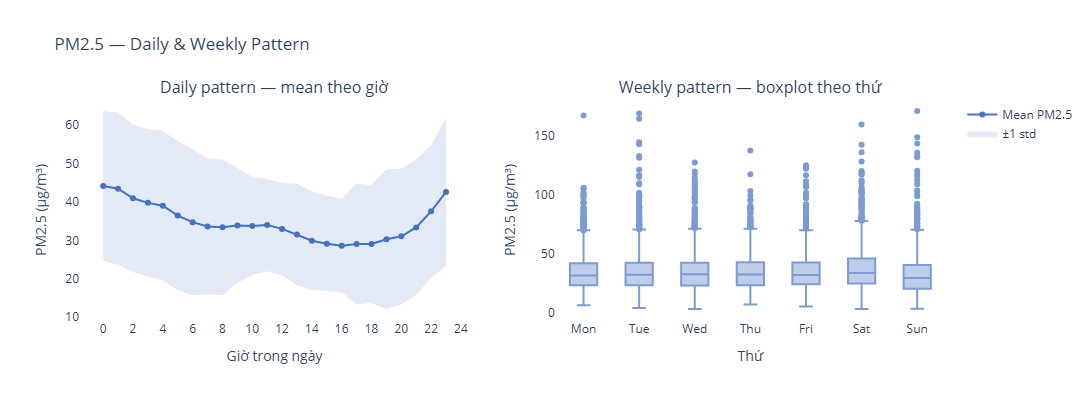

In [26]:
# ════════════════════════════════════════════════════════════
# 2. DAILY & WEEKLY PATTERN
# ════════════════════════════════════════════════════════════
df_pattern = pm25_imputed[['pm25_avg']].dropna().copy()
df_pattern['hour']        = df_pattern.index.hour
df_pattern['day_of_week'] = df_pattern.index.dayofweek
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig2 = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Daily pattern — mean theo giờ', 'Weekly pattern — boxplot theo thứ']
)

# Daily pattern
hourly = df_pattern.groupby('hour')['pm25_avg'].agg(['mean', 'std']).reset_index()
fig2.add_trace(go.Scatter(
    x=hourly['hour'], y=hourly['mean'],
    mode='lines+markers',
    line=dict(color='#4472c4', width=2),
    marker=dict(size=6),
    name='Mean PM2.5',
), row=1, col=1)
fig2.add_trace(go.Scatter(
    x=pd.concat([hourly['hour'], hourly['hour'][::-1]]),
    y=pd.concat([hourly['mean'] + hourly['std'], (hourly['mean'] - hourly['std'])[::-1]]),
    fill='toself', fillcolor='rgba(68,114,196,0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='±1 std', showlegend=True,
), row=1, col=1)

# Weekly pattern
for dow in range(7):
    vals = df_pattern[df_pattern['day_of_week'] == dow]['pm25_avg']
    fig2.add_trace(go.Box(
        y=vals, name=dow_labels[dow],
        marker_color='#4472c4', opacity=0.7,
        showlegend=False,
    ), row=1, col=2)

fig2.update_layout(
    title='PM2.5 — Daily & Weekly Pattern',
    height=400, plot_bgcolor='white'
)
fig2.update_xaxes(title_text='Giờ trong ngày', dtick=2, row=1, col=1)
fig2.update_xaxes(title_text='Thứ', row=1, col=2)
fig2.update_yaxes(title_text='PM2.5 (μg/m³)', row=1, col=1)
fig2.update_yaxes(title_text='PM2.5 (μg/m³)', row=1, col=2)
fig2.show()

### * Kết luận

- Daily pattern rõ → `hour_sin/cos`, `lag_24h` quan trọng
- Weekly pattern mờ do Median và IQR gần như giống nhau tất cả 7 ngày (Không có sự khác biệt rõ weekday vs weekend) → `day_of_week`/`is_weekend` ít quan trọng

## 2.4. Rolling Mean - Seasonal Trend

In [44]:
pm25_imputed.head(5)

,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct,is_missing_pm25,gap_group,is_imputed
datetime,,,,,,,,,
2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0,False,1,0
2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0,False,1,0
2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0,False,1,0
2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,NaN,30.950000,100.0,False,1,0
2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,NaN,30.216667,100.0,False,1,0


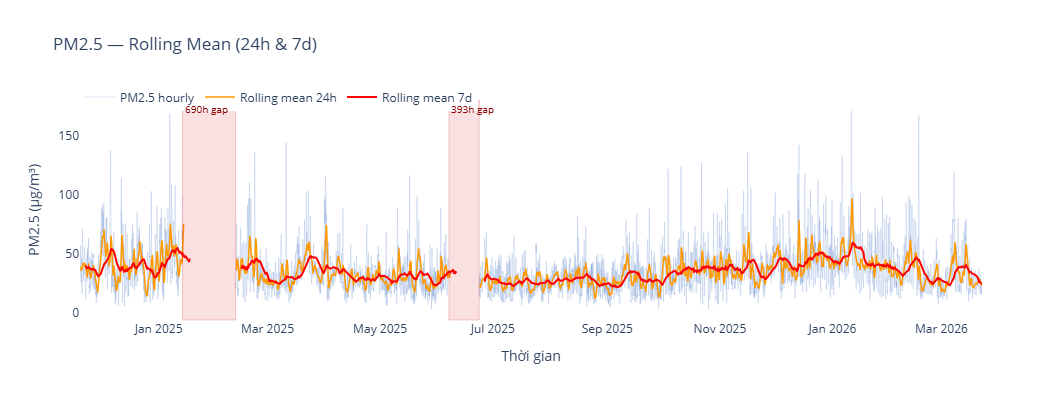

In [43]:
import plotly.graph_objects as go

fig = go.Figure()

# Raw signal (mờ để không lấn át)
fig.add_trace(go.Scatter(
    x=pm25_imputed.index,
    y=pm25_imputed['pm25_avg'],
    mode='lines',
    line=dict(color='rgba(68,114,196,0.25)', width=0.7),
    name='PM2.5 hourly',
))

# Rolling mean 24h
fig.add_trace(go.Scatter(
    x=pm25_imputed.index,
    y=pm25_imputed['pm25_avg'].rolling(24, min_periods=12).mean(),
    mode='lines',
    line=dict(color='#ff9900', width=1.5),
    name='Rolling mean 24h',
))

# Rolling mean 7d
fig.add_trace(go.Scatter(
    x=pm25_imputed.index,
    y=pm25_imputed['pm25_avg'].rolling(24*7, min_periods=24*3).mean(),
    mode='lines',
    line=dict(color='#ff0000', width=2),
    name='Rolling mean 7d',
))

# Đánh dấu 2 large gap
for _, row in gap_summary[gap_summary['gap_hours'] > 168].iterrows():
    fig.add_vrect(
        x0=row['gap_start'],
        x1=row['gap_end'] + pd.Timedelta(hours=1),
        fillcolor='rgba(220,50,50,0.15)',
        line=dict(color='rgba(200,0,0,0.4)', width=0.5),
        annotation_text=f"{row['gap_hours']}h gap",
        annotation_position='top left',
        annotation_font=dict(size=10, color='darkred'),
    )

fig.update_layout(
    title='PM2.5 — Rolling Mean (24h & 7d)',
    xaxis_title='Thời gian',
    yaxis_title='PM2.5 (μg/m³)',
    height=400,
    plot_bgcolor='white',
    hovermode='x unified',
    legend=dict(orientation='h', y=1.08),
)
fig.show()

### * Nhận xét:
- Seasonal trend mùa khô/mưa rõ  → cần `month_sin/cos` trong FE
- Rolling 24h ổn định             → `rolling_mean_24h` là feature tin cậy  
- Không jump sau large gap        → `dropna()` khi FE là đủ

## 2.5. ACF & PACF

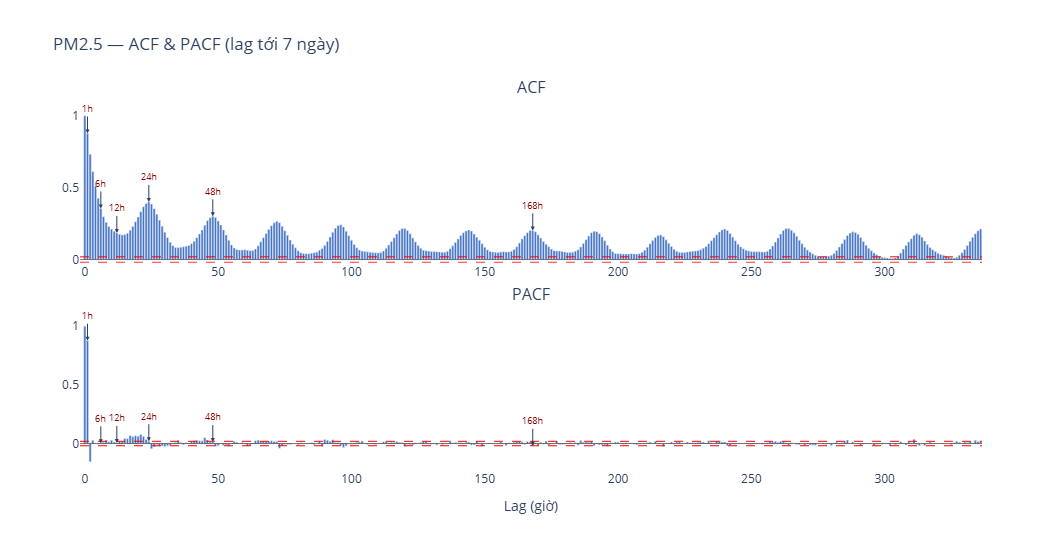


ACF tại các lag quan trọng:
  lag_  1h: 0.876
  lag_  2h: 0.732
  lag_  3h: 0.611
  lag_  6h: 0.355
  lag_ 12h: 0.185
  lag_ 24h: 0.401
  lag_ 48h: 0.300
  lag_ 72h: 0.266
  lag_168h: 0.202


In [28]:
# ════════════════════════════════════════════════════════════
# 4. ACF & PACF
# ════════════════════════════════════════════════════════════
nlags = 48 * 7  # 7 ngày

acf_vals  = acf(pm25_clean,  nlags=nlags, fft=True)
pacf_vals = pacf(pm25_clean, nlags=min(nlags, len(pm25_clean)//2 - 1))
lags      = np.arange(len(acf_vals))
conf      = 1.96 / np.sqrt(len(pm25_clean))

fig4 = make_subplots(rows=2, cols=1, subplot_titles=['ACF', 'PACF'], vertical_spacing=0.12)

for vals, row, name in [(acf_vals, 1, 'ACF'), (pacf_vals, 2, 'PACF')]:
    l = np.arange(len(vals))
    # Bars
    fig4.add_trace(go.Bar(
        x=l, y=vals, marker_color='#4472c4', name=name, showlegend=False,
    ), row=row, col=1)
    # Confidence interval
    fig4.add_hline(y=conf,  line=dict(color='red', dash='dash', width=1), row=row, col=1)
    fig4.add_hline(y=-conf, line=dict(color='red', dash='dash', width=1), row=row, col=1)
    fig4.add_hline(y=0,     line=dict(color='black', width=0.5),           row=row, col=1)

    # Đánh dấu lag quan trọng
    for lag_mark in [1, 6, 12, 24, 48, 168]:
        if lag_mark < len(vals):
            fig4.add_annotation(
                x=lag_mark, y=vals[lag_mark],
                text=f'{lag_mark}h', showarrow=True,
                arrowhead=2, arrowsize=0.8, ax=0, ay=-25,
                font=dict(size=9, color='darkred'),
                row=row, col=1,
            )

fig4.update_layout(
    title='PM2.5 — ACF & PACF (lag tới 7 ngày)',
    height=550, plot_bgcolor='white',
)
fig4.update_xaxes(title_text='Lag (giờ)', row=2, col=1)
fig4.show()

# In các lag nổi bật
print("\nACF tại các lag quan trọng:")
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    if lag < len(acf_vals):
        print(f"  lag_{lag:3d}h: {acf_vals[lag]:.3f}")

In [52]:
pm25_clean.head(5)

datetime
2024-11-19 10:00:00+00:00    29.139999
2024-11-19 11:00:00+00:00    29.150000
2024-11-19 12:00:00+00:00    31.783333
2024-11-19 13:00:00+00:00    30.950000
2024-11-19 14:00:00+00:00    30.216667
Name: pm25_avg, dtype: float64

In [54]:
print(f'NaN: {pm25_clean.isna().sum()} rows')

NaN: 0 rows


  Lag      ACF   ACF_CI±     PACF   PACF_CI±  PACF_sig?
----------------------------------------------------------
    1h   0.8762    0.0190   0.8763     0.0190          ✅
    2h   0.7316    0.0302  -0.1562     0.0190          ✅
    3h   0.6108    0.0361   0.0288     0.0190          ✅
    6h   0.3552    0.0435   0.0016     0.0190          ❌
   12h   0.1852    0.0468   0.0056     0.0190          ❌
   24h   0.4007    0.0527   0.0200     0.0190          ✅
   48h   0.3005    0.0599   0.0135     0.0190          ❌


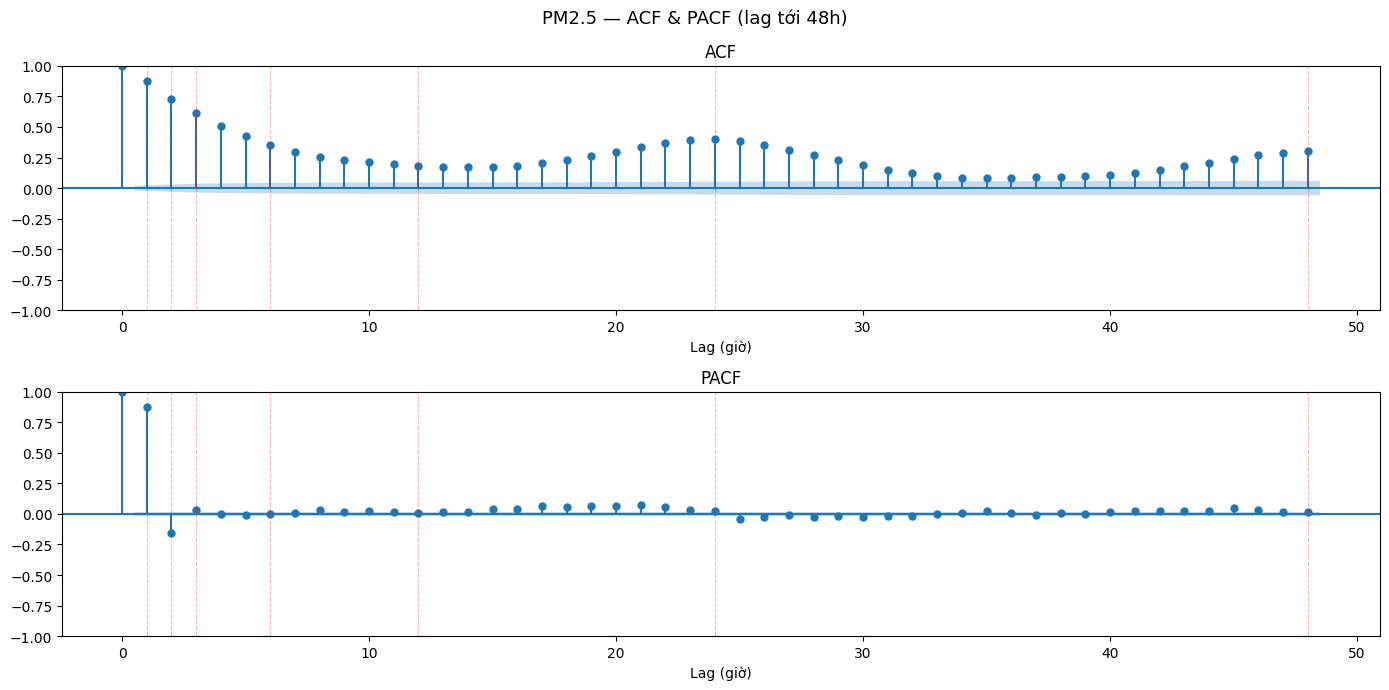

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── 1. Load data ──────────────────────────────────────────────
# Thay bằng cách load data của bạn, ví dụ:
# df = pd.read_csv("data.csv", index_col="datetime", parse_dates=True)
# pm25_clean = df["pm25_avg"].dropna()

# ── 2. Tính giá trị số ACF / PACF ────────────────────────────
max_lag = 48  # đủ để thấy lag 1–48h

acf_vals, acf_ci  = acf(pm25_clean,  nlags=max_lag, alpha=0.05)
pacf_vals, pacf_ci = pacf(pm25_clean, nlags=max_lag, alpha=0.05)

# confidence band width
acf_err  = acf_ci[:, 1]  - acf_vals
pacf_err = pacf_ci[:, 1] - pacf_vals

# ── 3. In bảng lag quan trọng ─────────────────────────────────
key_lags = [1, 2, 3, 6, 12, 24, 48]
print(f"{'Lag':>5} {'ACF':>8} {'ACF_CI±':>9} {'PACF':>8} {'PACF_CI±':>10} {'PACF_sig?':>10}")
print("-" * 58)
for lag in key_lags:
    sig = "✅" if abs(pacf_vals[lag]) > pacf_err[lag] else "❌"
    print(f"{lag:>5}h {acf_vals[lag]:>8.4f} {acf_err[lag]:>9.4f} "
          f"{pacf_vals[lag]:>8.4f} {pacf_err[lag]:>10.4f} {sig:>10}")

# ── 4. Vẽ biểu đồ ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("PM2.5 — ACF & PACF (lag tới 48h)", fontsize=13)

plot_acf(pm25_clean,  lags=max_lag, ax=axes[0], title="ACF")
plot_pacf(pm25_clean, lags=max_lag, ax=axes[1], title="PACF", method="ywm")

for ax in axes:
    for lag in key_lags:
        ax.axvline(lag, color="red", alpha=0.3, linestyle="--", linewidth=0.8)
    ax.set_xlabel("Lag (giờ)")

plt.tight_layout()
plt.show()

### * Nhận xét:

1. Phân tích ACF (Autocorrelation)
- Biểu đồ ACF cho thấy các cột xanh giảm dần rất chậm (Tail off) và có xu hướng lặp lại:
- Tính phụ thuộc cao (Persistence): Các lag đầu tiên (1h, 2h, 3h) cực kỳ cao (0.87, 0.73, 0.61). Điều này có nghĩa là nếu giờ trước không khí ô nhiễm, thì giờ sau khả năng rất cao vẫn sẽ ô nhiễm. Dữ liệu PM2.5 có tính "ì" lớn.
- Chu kỳ ngày đêm (Seasonality): Bạn hãy nhìn vào "điểm gồ" lên ở mốc Lag 24h và 48h. Mối tương quan tăng lên tại các điểm này khẳng định dữ liệu có chu kỳ 24 giờ rất rõ rệt (Ví dụ: 8h sáng hôm nay rất giống 8h sáng hôm qua).

2. Phân tích PACF (Partial Autocorrelation)
- Biểu đồ PACF giúp chúng ta loại bỏ các tác động dây chuyền để xem giờ nào thực sự ảnh hưởng trực tiếp đến hiện tại:
- Cắt cụt sau Lag 3 (Cut off): Bảng thống kê bên trên cho thấy chỉ có Lag 1h, 2h, 3h là có ý nghĩa thống kê (dấu tích xanh ✅).
- Lag 1h (0.8762): Đây là yếu tố quyết định nhất. Trạng thái của 1 giờ trước đóng góp gần như toàn bộ thông tin để dự báo giờ hiện tại.
- Từ Lag 4h trở đi: Hầu hết các cột nằm trong vùng xanh (nhiễu). Điều này có nghĩa là sau khi đã biết thông tin của 3 giờ gần nhất, thì việc biết thêm thông tin của 6h hay 12h trước không giúp ích thêm nhiều cho mô hình.

In [31]:
# Verify daily & weekly seasonality
acf_vals_long = acf(pm25_clean, nlags=200)

# Và check stationarity
from statsmodels.tsa.stattools import adfuller
result = adfuller(pm25_clean)
print(f"ADF p-value: {result[1]:.4f}")
# p > 0.05 → cần differencing trước khi dùng ARIMA

ADF p-value: 0.0000


=> ADF p-value = 0.0000, p < 0.05 → chuỗi DỪNG (stationary)

Không cần differencing — dùng raw pm25 làm feature/target được

Gợi ý feature set cho ML (XGBoost / LightGBM):
```
features = [
    "pm25_lag1",    # PACF significant
    "pm25_lag2",    # PACF significant
    "pm25_lag24",   # daily seasonality (cần verify)
    "rolling_mean_3h",
    "rolling_mean_24h",
    "hour_sin", "hour_cos",   # time encoding
]
```

### * Kết luận Feature Engineering (Sau phân tích ACF/PACF & EDA)


| Feature | Nguồn gốc | Trạng thái | Ghi chú kỹ thuật |
| :--- | :--- | :---: | :--- |
| **lag_1h** | PACF significant ✅ | **Bắt buộc** | Biến dự báo quan trọng nhất (Dominant predictor). |
| **lag_2h** | PACF significant ✅ | **Bắt buộc** | Hệ số âm (~ -0.20), đóng vai trò hiệu chỉnh (Correction term). |
| **lag_24h, lag_25h** | ACF Peak + Daily Pattern | **Bắt buộc** | Nắm bắt tính chu kỳ ngày (Daily Seasonality). |
| **hour_sin / cos** | EDA Daily Pattern | **Bắt buộc** | Mã hóa thuộc tính thời gian dạng vòng lặp ngày. |
| **month_sin / cos** | EDA Seasonal Trend | **Bắt buộc** | Nắm bắt xu hướng thay đổi theo mùa trong năm. |
| **rolling_mean_24h** | EDA Trend ngắn hạn | **Bắt buộc** | Đại diện cho mức độ ô nhiễm nền của ngày hiện tại. |
| **rolling_mean_3h** | ACF giảm chậm | **Thêm mới** | Nắm bắt tính "ì" (Persistence) của nồng độ bụi. |
| **rolling_std_6h** | Spike Volatility | **Thêm mới** | Tín hiệu cảnh báo các đợt biến động đột ngột. |
| **lag_3h – lag_6h** | EDA Checklist | *Dự phòng* | Hạ ưu tiên do PACF không còn ý nghĩa thống kê rõ rệt. |
| **lag_168h** | EDA Weekly | *Ít kỳ vọng* | PACF không rõ, chỉ thêm nếu mô hình có dấu hiệu thiếu chu kỳ tuần. |
| **day_of_week / weekend**| EDA Weekly | *Ít kỳ vọng* | Giữ lại để mô hình phân biệt ngày nghỉ và ngày đi làm. |

**Feature set cuối (theo thứ tự ưu tiên):**

FEATURES = [
    # Tier 1 — PACF confirmed, bắt buộc
    "lag_1h", "lag_2h",

    # Tier 2 — Daily seasonality, bắt buộc
    "lag_24h", "lag_25h",
    "hour_sin", "hour_cos",
    "rolling_mean_24h",

    # Tier 3 — Seasonal + trend
    "month_sin", "month_cos",
    "rolling_mean_3h",
    "rolling_std_6h",

    # Tier 4 — Thêm vào, để model tự lọc
    "lag_3h", "lag_6h",
    "lag_168h",
    "rolling_mean_7d",
    "day_of_week", "is_weekend",
]

HORIZONS = [1, 2, 3, 4, 5, 6]  # direct strategy

### * Kết luận Model Training Strategy:
Direct Multi-Output (train model riêng cho từng horizon t+1 → t+6), không dùng recursive để tránh error accumulation.

In [32]:
weather_df.head(5)

,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
10,2024-11-19 10:00:00+00:00,32.0,55,0.0,1.57,59,1006.8,910.0,-1.345753,-0.808610
11,2024-11-19 11:00:00+00:00,30.9,59,0.1,0.29,211,1007.6,150.0,0.149361,0.248579
12,2024-11-19 12:00:00+00:00,29.3,68,0.0,1.37,204,1008.4,245.0,0.557229,1.251557
13,2024-11-19 13:00:00+00:00,26.6,77,0.2,0.78,105,1009.5,95.0,-0.753422,0.201879
14,2024-11-19 14:00:00+00:00,26.6,79,0.1,1.10,309,1010.0,85.0,0.854861,-0.692252


---

# EDA - Meteo

In [47]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11726 entries, 10 to 11735
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   datetime               11726 non-null  datetime64[ns, UTC]
 1   temperature_2m         11726 non-null  float64            
 2   relative_humidity_2m   11726 non-null  int64              
 3   precipitation          11726 non-null  float64            
 4   wind_speed_10m         11726 non-null  float64            
 5   wind_direction_10m     11726 non-null  int64              
 6   surface_pressure       11726 non-null  float64            
 7   boundary_layer_height  11726 non-null  float64            
 8   wind_u                 11726 non-null  float64            
 9   wind_v                 11726 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(7), int64(2)
memory usage: 1007.7 KB


In [48]:
weather_df.head(5)

,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
10,2024-11-19 10:00:00+00:00,32.0,55,0.0,1.57,59,1006.8,910.0,-1.345753,-0.808610
11,2024-11-19 11:00:00+00:00,30.9,59,0.1,0.29,211,1007.6,150.0,0.149361,0.248579
12,2024-11-19 12:00:00+00:00,29.3,68,0.0,1.37,204,1008.4,245.0,0.557229,1.251557
13,2024-11-19 13:00:00+00:00,26.6,77,0.2,0.78,105,1009.5,95.0,-0.753422,0.201879
14,2024-11-19 14:00:00+00:00,26.6,79,0.1,1.10,309,1010.0,85.0,0.854861,-0.692252


In [35]:
weather_df.describe()

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
count,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000,11726.000000
mean,27.345216,76.789528,0.247757,1.889033,185.606345,1009.084701,553.184377,-0.025693,0.398321
std,3.145368,17.365698,1.054782,0.999279,98.104275,2.406897,518.727565,1.478327,1.490813
min,17.900000,22.000000,0.000000,0.000000,1.000000,1001.800000,10.000000,-5.205118,-5.141389
25%,25.000000,66.000000,0.000000,1.130000,119.000000,1007.400000,165.000000,-1.095619,-0.653151
50%,26.600000,81.000000,0.000000,1.770000,178.000000,1009.000000,370.000000,-0.045342,0.452548
75%,29.500000,91.000000,0.000000,2.530000,258.000000,1010.700000,780.000000,0.905893,1.541835
max,37.300000,100.000000,18.800000,6.510000,360.000000,1017.100000,2800.000000,6.150000,5.802971


In [36]:
meteo = (
    weather_df
    .set_index("datetime")
    .sort_index()
 )
print(meteo.shape)
print(meteo.index.min(), meteo.index.max())

full_range = pd.date_range(meteo.index.min(), meteo.index.max(), freq="h")
full_range.shape

(11726, 9)
2024-11-19 10:00:00+00:00 2026-03-22 23:00:00+00:00


(11726,)

In [37]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11726 entries, 10 to 11735
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   datetime               11726 non-null  datetime64[ns, UTC]
 1   temperature_2m         11726 non-null  float64            
 2   relative_humidity_2m   11726 non-null  int64              
 3   precipitation          11726 non-null  float64            
 4   wind_speed_10m         11726 non-null  float64            
 5   wind_direction_10m     11726 non-null  int64              
 6   surface_pressure       11726 non-null  float64            
 7   boundary_layer_height  11726 non-null  float64            
 8   wind_u                 11726 non-null  float64            
 9   wind_v                 11726 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(7), int64(2)
memory usage: 1007.7 KB


In [49]:
weather_df.isna().sum()

datetime                 0
temperature_2m           0
relative_humidity_2m     0
precipitation            0
wind_speed_10m           0
wind_direction_10m       0
surface_pressure         0
boundary_layer_height    0
wind_u                   0
wind_v                   0
dtype: int64

In [42]:
meteo_df = weather_df.copy()
meteo_df = meteo_df.set_index("datetime") 

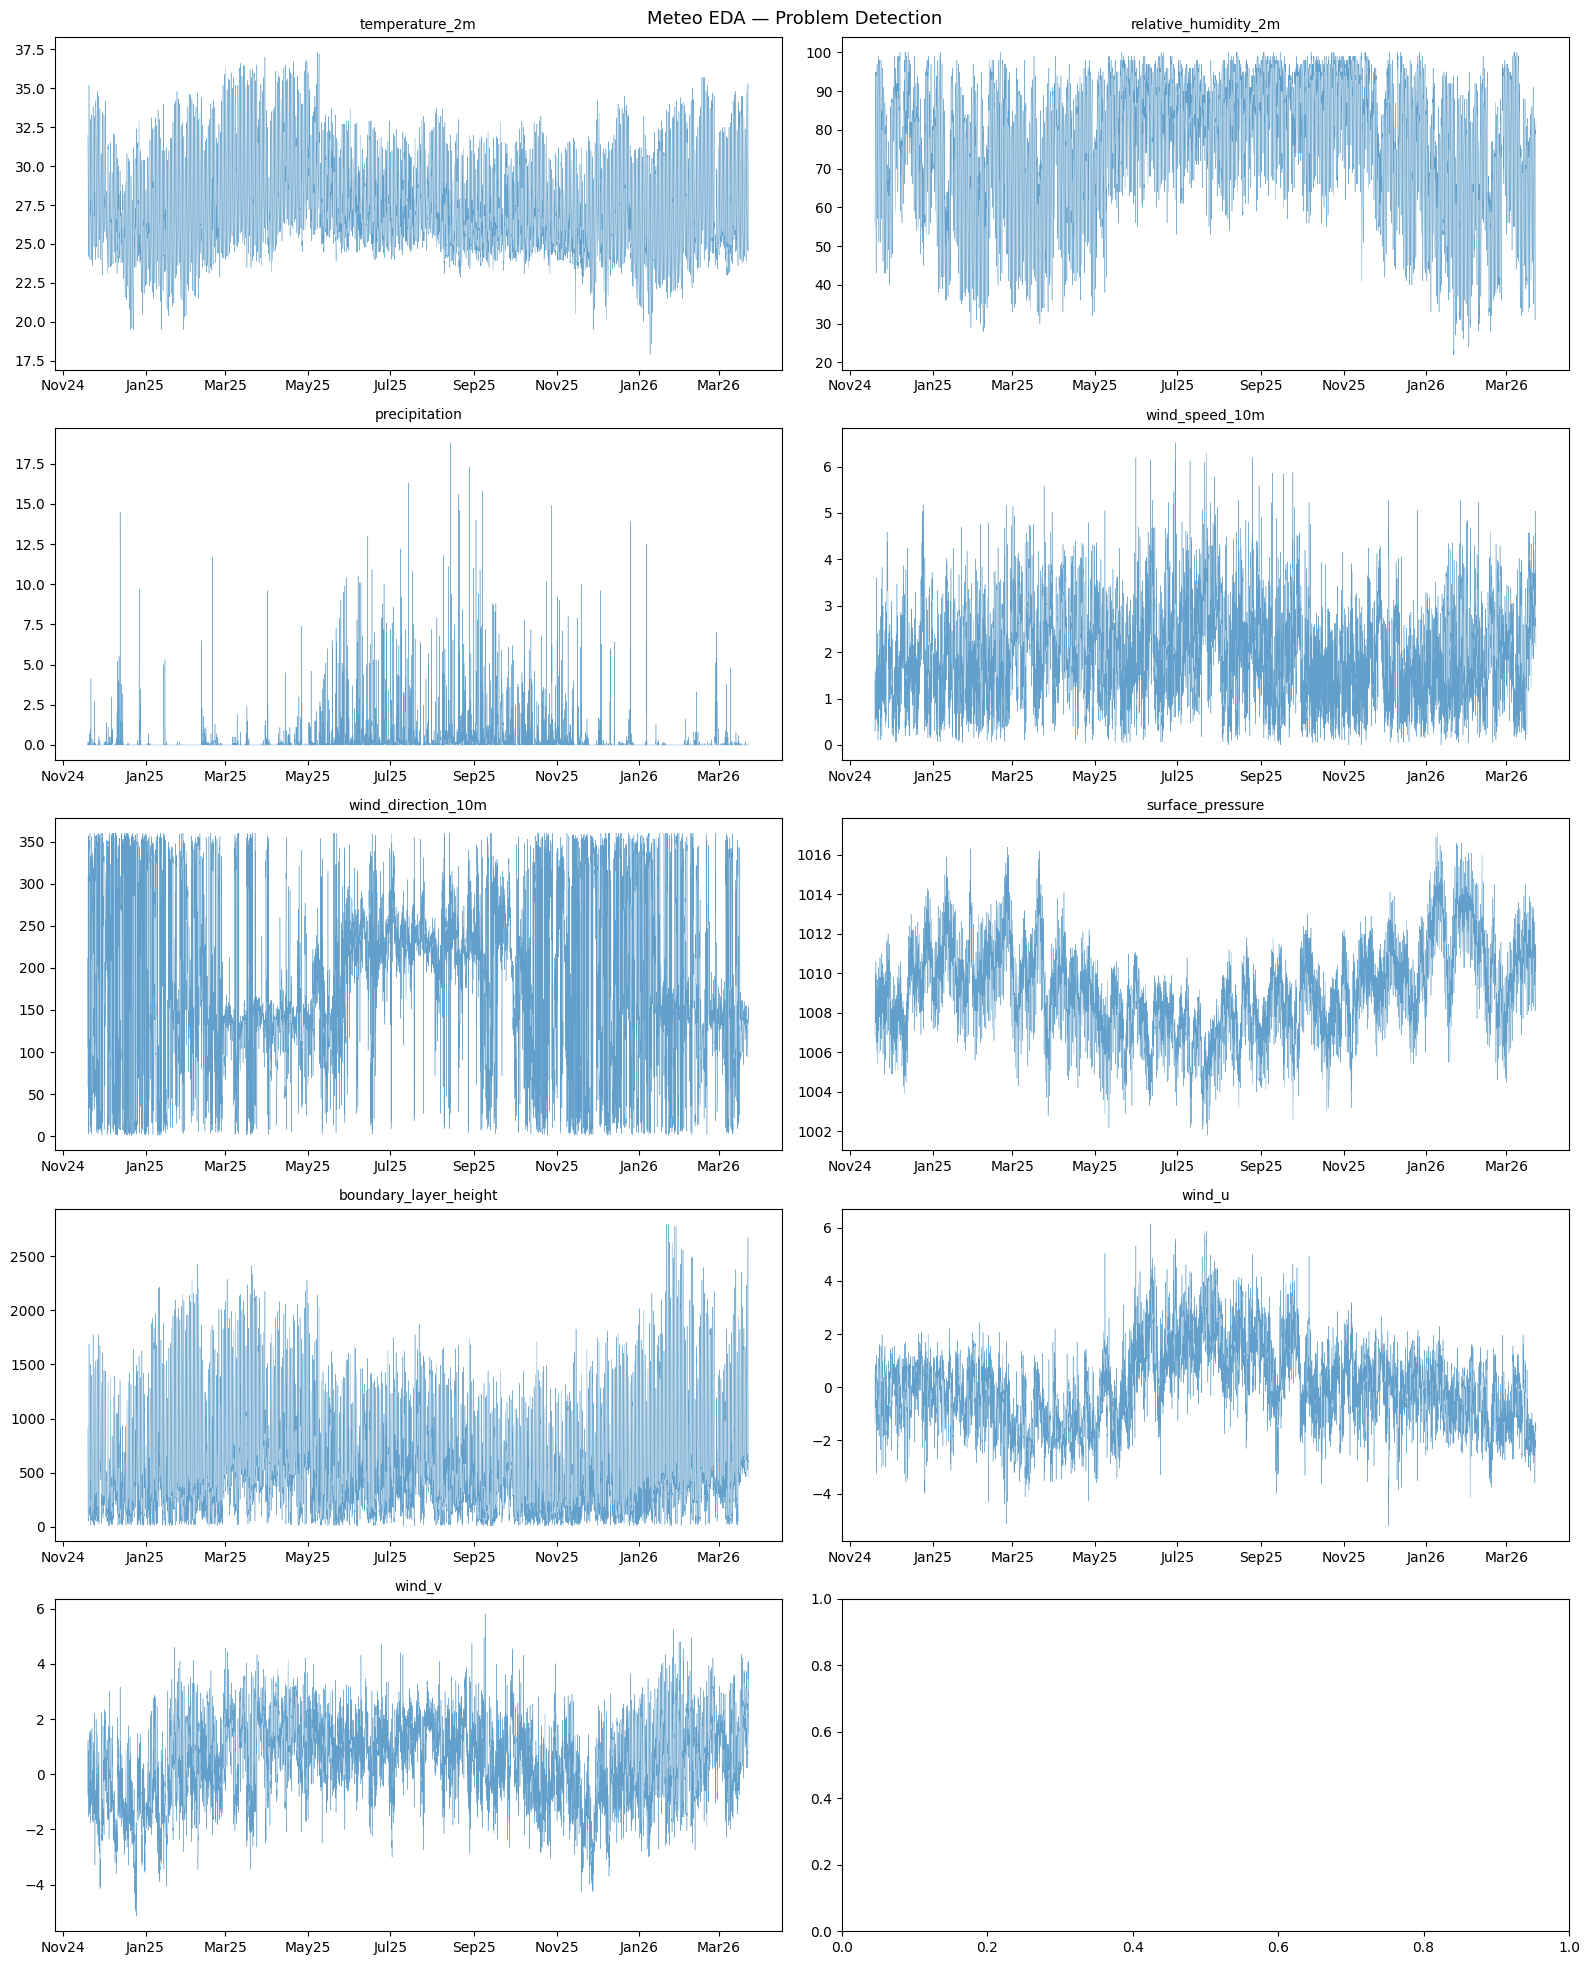

Humidity = 100%: 52 giờ (0.4%)

BLH ≤ 20m: 182 giờ
datetime
0      5
9      1
10     1
11     5
12     8
13    12
14    13
15     8
16    14
17    16
18    17
19    13
20    10
21    17
22    21
23    21
Name: count, dtype: int64


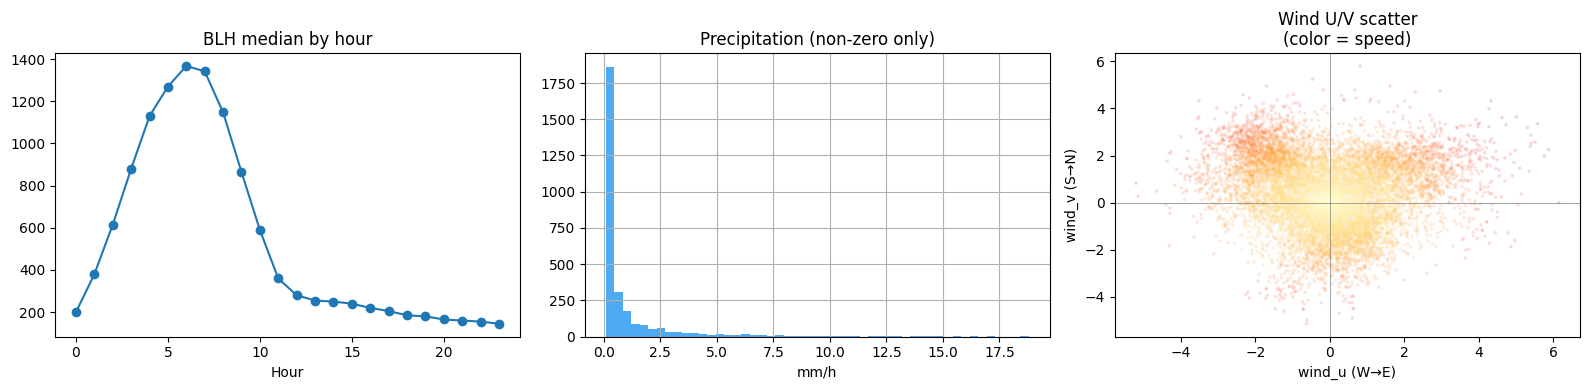


Alignment check:
_merge
both          10649
right_only     1077
left_only         0
Name: count, dtype: int64


In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

METEO_COLS = [
    "temperature_2m",
    "relative_humidity_2m", 
    "precipitation",
    "wind_speed_10m",
    "wind_direction_10m",
    "surface_pressure",
    "boundary_layer_height",
    "wind_u",
    "wind_v"
]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
fig.suptitle("Meteo EDA — Problem Detection", fontsize=13)
axes = axes.flatten()

# ── 1. Time series từng feature → detect jump/drift/flatline ──
for i, col in enumerate(METEO_COLS):
    axes[i].plot(meteo_df.index, meteo_df[col], linewidth=0.3, alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%b%y"))
    axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.tight_layout()
plt.show()

# ── 2. Humidity = 100% bao nhiêu giờ? ─────────────────────────
rh100 = (meteo_df["relative_humidity_2m"] == 100).sum()
print(f"Humidity = 100%: {rh100} giờ ({rh100/len(meteo_df)*100:.1f}%)")

# ── 3. BLH = 10m (min) bao nhiêu giờ, xảy ra lúc mấy giờ? ───
blh_low = meteo_df[meteo_df["boundary_layer_height"] <= 20]
print(f"\nBLH ≤ 20m: {len(blh_low)} giờ")
print(blh_low.index.hour.value_counts().sort_index())

# ── 4. BLH theo giờ trong ngày → kiểm tra diurnal cycle ───────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

meteo_df.groupby(meteo_df.index.hour)["boundary_layer_height"].median().plot(
    ax=axes[0], marker="o", title="BLH median by hour"
)
axes[0].set_xlabel("Hour")

# ── 5. Precipitation distribution ─────────────────────────────
meteo_df[meteo_df["precipitation"] > 0]["precipitation"].hist(
    bins=50, ax=axes[1], color="#2196F3", alpha=0.8
)
axes[1].set_title("Precipitation (non-zero only)")
axes[1].set_xlabel("mm/h")

# ── 6. Wind rose kiểm tra wind_direction ──────────────────────
axes[2].scatter(
    meteo_df["wind_u"], meteo_df["wind_v"],
    alpha=0.1, s=3, c=meteo_df["wind_speed_10m"], cmap="YlOrRd"
)
axes[2].axhline(0, color="gray", lw=0.5)
axes[2].axvline(0, color="gray", lw=0.5)
axes[2].set_title("Wind U/V scatter\n(color = speed)")
axes[2].set_xlabel("wind_u (W→E)")
axes[2].set_ylabel("wind_v (S→N)")

plt.tight_layout()
plt.show()

# ── 7. Temporal alignment check với pm25 ──────────────────────
df_merged = pd.merge(
    pm25_clean.rename("pm25"),
    meteo_df,
    left_index=True, right_index=True,
    how="outer", indicator=True
)
print("\nAlignment check:")
print(df_merged["_merge"].value_counts())
# both = overlap, left_only = pm25 không có meteo, right_only = meteo không có pm25

## 2.6. Tương quan PM2.5 ↔ Meteo features
dùng `inner join` để merge 2 dataset -> dùng để tính Correlation only

In [44]:
meteo_df = weather_df.copy()
meteo_df = meteo_df.set_index("datetime")

In [45]:
# !pip install seaborn

Merged: 10649 rows

── Same-time correlation ──
              feature  pearson_r  spearman_r sig
       wind_speed_10m     -0.336      -0.364   ✅
               wind_v     -0.290      -0.353   ✅
     surface_pressure      0.241       0.236   ✅
        precipitation     -0.064      -0.126   ✅
 relative_humidity_2m     -0.113      -0.094   ✅
   wind_direction_10m      0.106       0.091   ✅
boundary_layer_height      0.025      -0.063   ✅
               wind_u      0.022       0.047   ✅
       temperature_2m      0.004       0.002   ❌

── Lag correlation (Spearman) ──
                       lag_0h  lag_1h  lag_2h  lag_3h  lag_6h  lag_12h  lag_24h best_lag  best_r
temperature_2m          0.002  -0.067  -0.123  -0.167  -0.238   -0.173    0.017   lag_6h  -0.238
relative_humidity_2m   -0.094  -0.043  -0.004   0.025   0.069    0.017   -0.153  lag_24h  -0.153
precipitation          -0.126  -0.123  -0.114  -0.108  -0.101   -0.074   -0.147  lag_24h  -0.147
wind_speed_10m         -0.364  -0.390  -

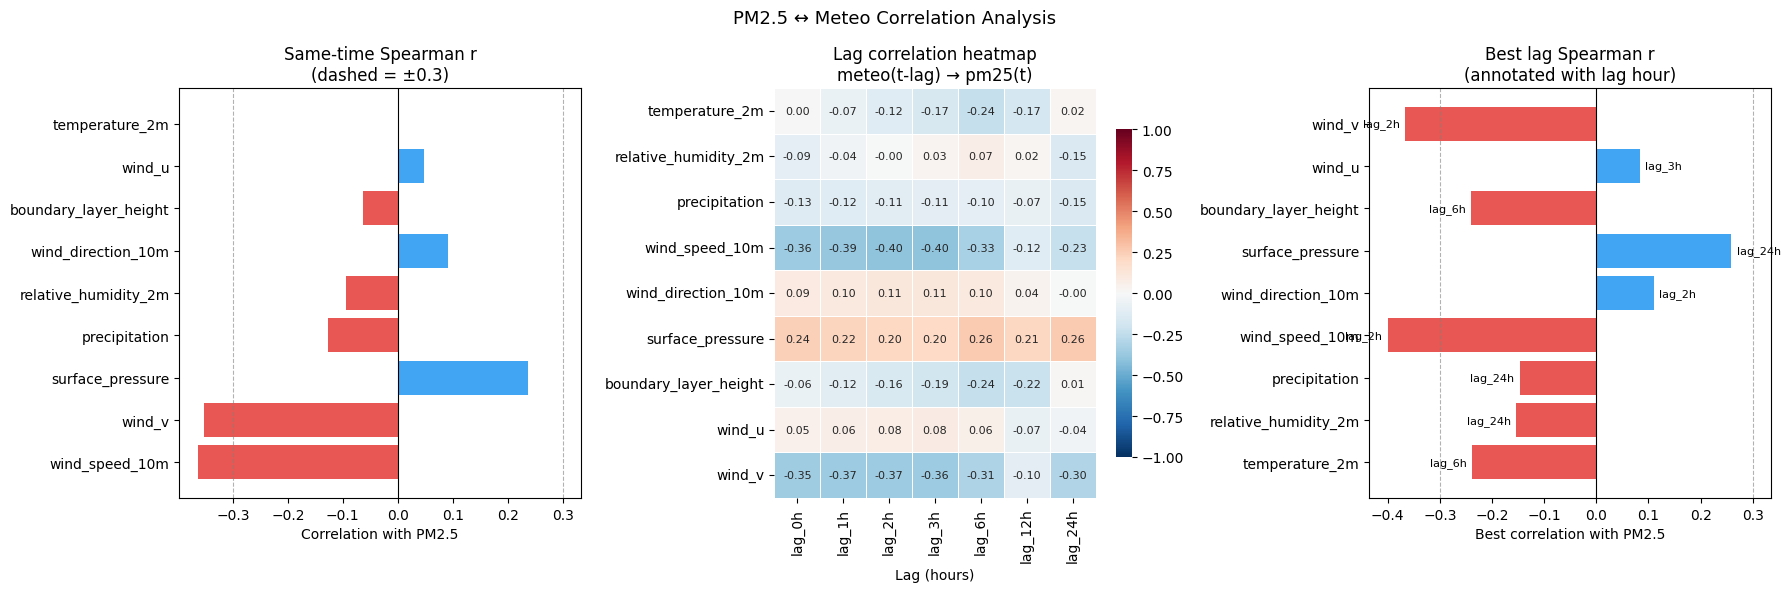

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 0. Merge ──────────────────────────────────────────────────
df = pd.merge(
    pm25_clean.rename("pm25"),
    meteo_df,
    left_index=True, right_index=True,
    how="inner"
)
print(f"Merged: {len(df)} rows")

METEO_COLS = [
    "temperature_2m", "relative_humidity_2m", "precipitation",
    "wind_speed_10m", "wind_direction_10m", "surface_pressure",
    "boundary_layer_height", "wind_u", "wind_v"
]

# ── 1. Same-time Pearson + Spearman ───────────────────────────
results = []
for col in METEO_COLS:
    tmp = df[["pm25", col]].dropna()
    pr, pp = stats.pearsonr(tmp["pm25"], tmp[col])
    sr, sp = stats.spearmanr(tmp["pm25"], tmp[col])
    results.append({
        "feature"    : col,
        "pearson_r"  : round(pr, 3),
        "spearman_r" : round(sr, 3),
        "sig"        : "✅" if sp < 0.05 else "❌"
    })

corr_df = pd.DataFrame(results).sort_values("spearman_r", key=abs, ascending=False)
print("\n── Same-time correlation ──")
print(corr_df.to_string(index=False))

# ── 2. Lag correlation (meteo → pm25) ─────────────────────────
LAG_HOURS = [0, 1, 2, 3, 6, 12, 24]
lag_results = {}

for col in METEO_COLS:
    lag_results[col] = []
    for lag in LAG_HOURS:
        r = df["pm25"].corr(df[col].shift(lag), method="spearman")
        lag_results[col].append(round(r, 3))

lag_df = pd.DataFrame(lag_results, index=[f"lag_{l}h" for l in LAG_HOURS]).T
lag_df["best_lag"] = lag_df.abs().idxmax(axis=1)
lag_df["best_r"]   = lag_df[lag_df.columns[:-1]].apply(
    lambda row: row[row.abs().idxmax()], axis=1
).round(3)

print("\n── Lag correlation (Spearman) ──")
print(lag_df.to_string())

# ── 3. Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("PM2.5 ↔ Meteo Correlation Analysis", fontsize=13)

# 3a. Same-time bar chart
colors = ["#2196F3" if v > 0 else "#E53935" for v in corr_df["spearman_r"]]
axes[0].barh(corr_df["feature"], corr_df["spearman_r"], color=colors, alpha=0.85)
axes[0].axvline(0,    color="black", lw=0.8)
axes[0].axvline( 0.3, color="gray",  lw=0.8, ls="--", alpha=0.6)
axes[0].axvline(-0.3, color="gray",  lw=0.8, ls="--", alpha=0.6)
axes[0].set_title("Same-time Spearman r\n(dashed = ±0.3)")
axes[0].set_xlabel("Correlation with PM2.5")

# 3b. Lag correlation heatmap
lag_plot = lag_df.drop(columns=["best_lag", "best_r"])
sns.heatmap(
    lag_plot, ax=axes[1],
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    linewidths=0.5, cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Lag correlation heatmap\nmeteo(t-lag) → pm25(t)")
axes[1].set_xlabel("Lag (hours)")

# 3c. Best lag summary
colors2 = ["#2196F3" if v > 0 else "#E53935" for v in lag_df["best_r"]]
axes[2].barh(lag_df.index, lag_df["best_r"], color=colors2, alpha=0.85)
for i, (r, l) in enumerate(zip(lag_df["best_r"], lag_df["best_lag"])):
    axes[2].text(r + 0.01 if r > 0 else r - 0.01, i,
                 f"{l}", va="center",
                 ha="left" if r > 0 else "right", fontsize=8)
axes[2].axvline(0,    color="black", lw=0.8)
axes[2].axvline( 0.3, color="gray",  lw=0.8, ls="--", alpha=0.6)
axes[2].axvline(-0.3, color="gray",  lw=0.8, ls="--", alpha=0.6)
axes[2].set_title("Best lag Spearman r\n(annotated with lag hour)")
axes[2].set_xlabel("Best correlation with PM2.5")

plt.tight_layout()
plt.show()

# Lưu Merged Dataset


In [56]:
pm25_imputed.head(5)

,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct,is_missing_pm25,gap_group,is_imputed
datetime,,,,,,,,,
2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0,False,1,0
2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0,False,1,0
2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0,False,1,0
2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,NaN,30.950000,100.0,False,1,0
2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,NaN,30.216667,100.0,False,1,0


In [58]:
meteo_df.head(5)

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
datetime,,,,,,,,,
2024-11-19 10:00:00+00:00,32.0,55,0.0,1.57,59,1006.8,910.0,-1.345753,-0.808610
2024-11-19 11:00:00+00:00,30.9,59,0.1,0.29,211,1007.6,150.0,0.149361,0.248579
2024-11-19 12:00:00+00:00,29.3,68,0.0,1.37,204,1008.4,245.0,0.557229,1.251557
2024-11-19 13:00:00+00:00,26.6,77,0.2,0.78,105,1009.5,95.0,-0.753422,0.201879
2024-11-19 14:00:00+00:00,26.6,79,0.1,1.10,309,1010.0,85.0,0.854861,-0.692252


In [60]:
import pandas as pd

pm25_to_merged = pm25_imputed[['pm25_avg']].copy()

# ── Align timezone ────────────────────────────────────────────
pm25_to_merged.index = pd.to_datetime(pm25_to_merged.index, utc=True)
meteo_df.index   = pd.to_datetime(meteo_df.index,   utc=True)

# ── Left merge — giữ toàn bộ index pm25, kể cả NaN ───────────
df = pd.merge(
    pm25_to_merged,
    meteo_df,
    left_index=True, right_index=True,
    how="left"
)

# ── Verify ────────────────────────────────────────────────────
print(f"Shape        : {df.shape}")
print(f"PM2.5 NaN    : {df['pm25_avg'].isna().sum()}")
print(f"Meteo NaN    : {df[meteo_df.columns].isna().sum().sum()}")
print(f"Index start  : {df.index[0]}")
print(f"Index end    : {df.index[-1]}")
print(f"Index is UTC : {df.index.tz}")
print(df.head(3))



# ── Save ──────────────────────────────────────────────────────
# 1. Định nghĩa path bằng pathlib
out_dir = PROJECT_ROOT / "data" / "processed"
out_path = out_dir / "clean_data.csv"

# 2. Tạo thư mục nếu chưa có (parents=True sẽ tạo cả data và processed nếu thiếu)
out_dir.mkdir(parents=True, exist_ok=True)

# 3. Lưu file
df.to_csv(out_path)

print(f"\nĐã tạo thư mục và lưu tại: {out_path}")

Shape        : (11726, 10)
PM2.5 NaN    : 1077
Meteo NaN    : 0
Index start  : 2024-11-19 10:00:00+00:00
Index end    : 2026-03-22 23:00:00+00:00
Index is UTC : UTC
                            pm25_avg  temperature_2m  relative_humidity_2m  \
datetime                                                                     
2024-11-19 10:00:00+00:00  29.139999            32.0                    55   
2024-11-19 11:00:00+00:00  29.150000            30.9                    59   
2024-11-19 12:00:00+00:00  31.783333            29.3                    68   

                           precipitation  wind_speed_10m  wind_direction_10m  \
datetime                                                                       
2024-11-19 10:00:00+00:00            0.0            1.57                  59   
2024-11-19 11:00:00+00:00            0.1            0.29                 211   
2024-11-19 12:00:00+00:00            0.0            1.37                 204   

                           surface_pressure

In [61]:
df.head(5)

,pm25_avg,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
datetime,,,,,,,,,,
2024-11-19 10:00:00+00:00,29.139999,32.0,55,0.0,1.57,59,1006.8,910.0,-1.345753,-0.808610
2024-11-19 11:00:00+00:00,29.150000,30.9,59,0.1,0.29,211,1007.6,150.0,0.149361,0.248579
2024-11-19 12:00:00+00:00,31.783333,29.3,68,0.0,1.37,204,1008.4,245.0,0.557229,1.251557
2024-11-19 13:00:00+00:00,30.950000,26.6,77,0.2,0.78,105,1009.5,95.0,-0.753422,0.201879
2024-11-19 14:00:00+00:00,30.216667,26.6,79,0.1,1.10,309,1010.0,85.0,0.854861,-0.692252
